In [51]:
# source: https://youtu.be/fxx_E0ojKrc 

In [52]:
# conda install -c conda-forge statsforecast utilsforecast

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from utilsforecast.plotting import plot_series # type: ignore
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *


In [54]:
df = pd.read_csv('dataset/daily_sales_french_bakery.csv', parse_dates=['ds'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57046 entries, 0 to 57045
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   unique_id   57046 non-null  str           
 1   ds          57046 non-null  datetime64[us]
 2   y           57046 non-null  float64       
 3   unit_price  57046 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 2.4 MB


In [55]:
df.sample(5)

,unique_id,ds,y,unit_price
27809,GAL POMME 6P,2021-12-31,12.00,12.00
4371,BOULE 200G,2022-07-18,10.80,1.20
44624,SACHET VIENNOISERIE,2022-06-30,0.00,4.00
2201,BANETTE,2021-11-21,30.45,1.05
13335,CROISSANT,2022-04-16,94.30,1.15


In [56]:
df['unique_id'].value_counts()

unique_id
BAGUETTE                  637
BANETTE                   637
BANETTINE                 637
BOULE 200G                637
BOULE 400G                637
                         ... 
REDUCTION SUCREES 24        1
SACHET DE VIENNOISERIE      1
TARTELETTE COCKTAIL         1
TROIS CHOCOLAT              1
TULIPE                      1
Name: count, Length: 148, dtype: int64

In [57]:
df = df.groupby('unique_id').filter(lambda x : len(x) >= 28)
df = df.drop('unit_price', axis=1)
df.sample(5)

,unique_id,ds,y
21137,FINANCIER,2021-06-12,0.0
27645,GAL POMME 6P,2021-07-20,0.0
34256,PAIN,2022-01-05,0.0
56704,VIK BREAD,2021-10-24,25.0
1645,BAGUETTE GRAINE,2022-02-05,0.0


In [59]:
df['unique_id'].value_counts()

unique_id
BAGUETTE              637
BANETTE               637
BANETTINE             637
BOULE 200G            637
BOULE 400G            637
                     ... 
RELIGIEUSE             71
SABLE F  P             68
DELICETROPICAL         63
VIENNOISE              61
PAIN SUISSE PEPITO     51
Name: count, Length: 121, dtype: int64

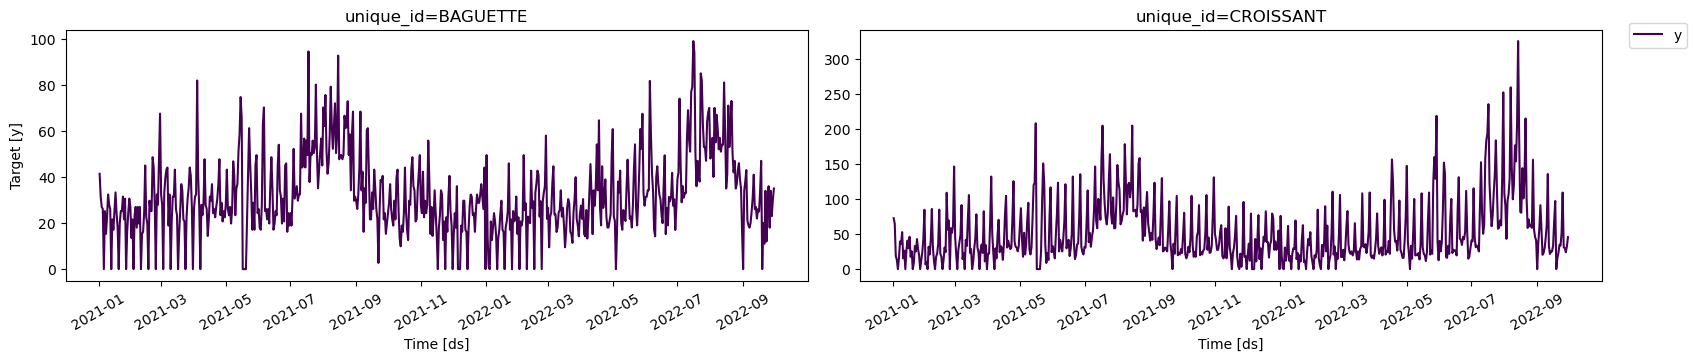

In [61]:
plot_series(df=df, ids=['BAGUETTE', 'CROISSANT'], palette='viridis')

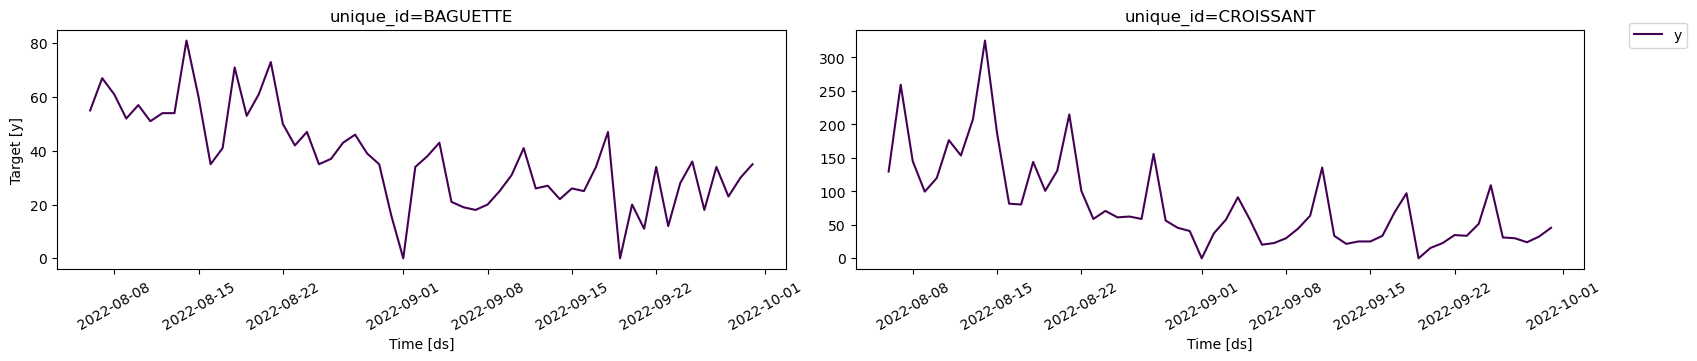

In [62]:

plot_series(df=df, ids=['BAGUETTE', 'CROISSANT'], palette='viridis', max_insample_length=56)

In [65]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

In [66]:
horizon = 7
models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7)
]

sf = StatsForecast(models=models, freq='D')
sf.fit(df=df)

preds = sf.predict(h=horizon)

d:\miniconda3\envs\global\Lib\site-packages\statsforecast\core.py:492: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


In [103]:
preds.head(20)

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-29,10.0,8.974359,2.857143,0.0
1,12 MACARON,2022-09-30,10.0,8.974359,2.857143,0.0
2,12 MACARON,2022-10-01,10.0,8.974359,2.857143,10.0
3,12 MACARON,2022-10-02,10.0,8.974359,2.857143,0.0
4,12 MACARON,2022-10-03,10.0,8.974359,2.857143,0.0
5,12 MACARON,2022-10-04,10.0,8.974359,2.857143,0.0
6,12 MACARON,2022-10-05,10.0,8.974359,2.857143,10.0
7,BAGUETTE,2022-10-01,35.0,32.152905,29.142857,28.0
8,BAGUETTE,2022-10-02,35.0,32.152905,29.142857,36.0
9,BAGUETTE,2022-10-03,35.0,32.152905,29.142857,18.0


In [104]:
preds = preds.reset_index()
preds

,index,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,0,12 MACARON,2022-09-29,10.000000,8.974359,2.857143,0.000000
1,1,12 MACARON,2022-09-30,10.000000,8.974359,2.857143,0.000000
2,2,12 MACARON,2022-10-01,10.000000,8.974359,2.857143,10.000000
3,3,12 MACARON,2022-10-02,10.000000,8.974359,2.857143,0.000000
4,4,12 MACARON,2022-10-03,10.000000,8.974359,2.857143,0.000000
...,...,...,...,...,...,...,...
842,842,VIK BREAD,2022-10-03,32.400002,14.566091,12.342857,0.000000
843,843,VIK BREAD,2022-10-04,32.400002,14.566091,12.342857,0.000000
844,844,VIK BREAD,2022-10-05,32.400002,14.566091,12.342857,0.000000
845,845,VIK BREAD,2022-10-06,32.400002,14.566091,12.342857,0.000000


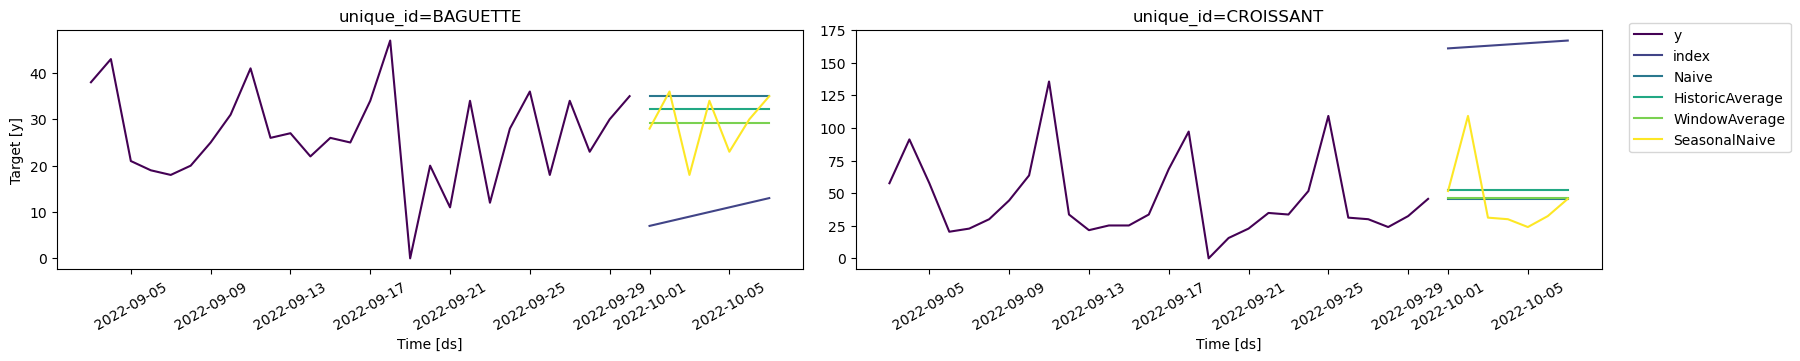

In [106]:
plot_series(df=df, ids=['BAGUETTE', 'CROISSANT'], forecasts_df=preds, max_insample_length=28, palette='viridis')